In [1]:
import pandas as pd
import matplotlib.pyplot as plt


import seaborn as sns
import random
import json

import constants
from model_utils import *

from ast import literal_eval
from pathlib import Path

import matplotlib.cm as cm

from matplotlib.colors import LinearSegmentedColormap

import numpy as np

In [2]:
#plt.style.use('ggplot')
sns.set_palette('hls', 18)
SPLIT = 'val-test'
model_type = constants.RectalCancerStagingData
base_dir = Path.cwd().parent

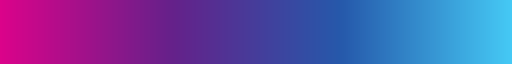

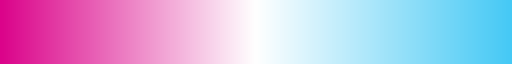

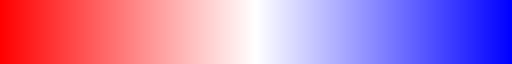

In [3]:
finomnia_palette = sns.color_palette(('#db038a',   # Pink
                                      '#66218a',   # Violet
                                      '#081c36',   # Dark Blue
                                      '#2659ab',   # blue
                                      '#45c9f5'))  # Light blue
finomnia_cmap = LinearSegmentedColormap.from_list("mio_cmap", [finomnia_palette[0], finomnia_palette[1], finomnia_palette[-2], finomnia_palette[-1]])
display(finomnia_cmap)
finomnia_cmap = LinearSegmentedColormap.from_list("mio_cmap", [finomnia_palette[0], '#ffffff', finomnia_palette[-1]])
display(finomnia_cmap)
red_white_blue = LinearSegmentedColormap.from_list("red_blue", ["#ff0000", '#ffffff', "#0000ff"])
display(red_white_blue)


In [4]:
greens = sns.color_palette('Greens', 10)
blues = sns.color_palette('Blues', 10)
oranges = sns.color_palette('Oranges', 10)
reds = sns.color_palette('Reds', 10)
purples = sns.color_palette('Purples', 10)
greys = sns.color_palette('Greys', 10)

In [5]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,          # i caption in LaTeX sono spesso 9-10pt
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 150,       # per la preview; il salvataggio usa il suo
})

# Total performance

In [6]:
scores = pd.read_csv(base_dir / 'data' / 'metrics' / 'scores.csv')
scores.rename(
    columns={
        constants.OPENAI_GPT_4_1_NANO: 'GPT 4.1 Nano',
        f'{constants.OPENAI_GPT_4_1_NANO}_few-shots': 'GPT 4.1 Nano\nMMR (lambda=1.0)',
        f'{constants.OPENAI_GPT_4_1_NANO}_MMR': 'GPT 4.1 Nano\nMMR (lambda=0.5)',
        constants.TUNED_GPT_4_1_NANO: 'GPT 4.1 Nano FT',
        constants.TUNED_GPT_4_1_NANO_OVERSAMPLE: 'GPT 4.1 Nano FT OS',
        constants.OPENAI_GPT_4_1_MINI: 'GPT 4.1 Mini',
        constants.OPENAI_GPT_4_1: 'GPT 4.1',
        constants.TUNED_GPT_4_1: 'GPT 4.1 FT',
        #constants.TUNED_GPT_4_1_OVERSAMPLING: 'gpt_4_1_tuned_oversampling',
        #f'few_shots_{constants.TUNED_GPT_4_1_OVERSAMPLING}': 'gpt_4_1_tuned_few_shots',
        #f'MMR_{constants.TUNED_GPT_4_1_OVERSAMPLING}': 'gpt_4_1_tuned_MMR',
        constants.OPENAI_GPT_5_4: 'GPT 5.4 reasoning',
        constants.MISTRAL_LARGE_3: 'Mistral Large 3',
        constants.CLAUDE_OPUS_4_6: 'Opus 4.6',
        #f'few_shots_{constants.CLAUDE_OPUS_4_6}': 'opus_4_6_few_shots',
        #f'MMR_{constants.CLAUDE_OPUS_4_6}': 'opus_4_6_MMR'
        constants.LLAMA_3_2_3B_TUNED: 'Llama 3.2 3B Tuned',
    },
    inplace=True
)

print(scores.split.value_counts())

train_scores = scores[scores.split=='train']
validation_scores = scores[scores.split=='validation']
test_scores = scores[scores.split=='test']

if SPLIT == 'val-test':
    scores = pd.concat([validation_scores, test_scores], ignore_index=True)
elif SPLIT == 'test':
    scores = test_scores
    
scores.set_index('id', inplace=True)

print(len(scores))

split
train         187
test           65
validation     63
Name: count, dtype: int64
128


In [7]:
scores.head()

,split,Opus 4.6,GPT 4.1 FT,GPT 4.1 Nano FT OS,GPT 4.1 Nano FT,GPT 4.1,GPT 4.1 Mini,GPT 4.1 Nano,GPT 4.1 Nano\nMMR (lambda=0.5),GPT 4.1 Nano\nMMR (lambda=1.0),GPT 5.4 reasoning,Llama 3.2 3B Tuned,Mistral Large 3
id,,,,,,,,,,,,,
51,validation,0.971751,0.887006,0.847458,0.743879,0.887006,0.830508,0.621469,0.706215,0.706215,0.830508,0.677966,0.943503
57,validation,0.811676,0.802260,0.689266,0.632768,0.868173,0.839925,0.734463,0.677966,0.687382,0.924670,0.612053,0.905838
61,validation,0.861582,0.852166,0.852166,0.852166,0.739171,0.795669,0.781689,0.649862,0.649862,0.745763,0.659134,0.739171
66,validation,0.974105,0.981168,0.971751,0.971751,0.934557,0.924670,0.762712,0.706215,0.677966,0.915254,0.677966,0.896422
73,validation,0.993409,0.996610,0.964972,0.988701,0.993837,0.908192,0.847458,0.847458,0.847458,1.000000,0.924670,0.996610


In [8]:
compared_models = [
    'GPT 4.1 Nano',
    'GPT 4.1 Nano\nMMR (lambda=1.0)',
    'GPT 4.1 Nano\nMMR (lambda=0.5)',
    #'GPT 4.1 Nano FT',
    #'GPT 4.1 Nano FT OS',
    #'Llama 3.2 3B Tuned',
    #'Llama 3.2 1B Tuned',
    #'GPT 4.1 Mini',
    #'GPT 4.1',
    #'GPT 4.1 FT',
    #'GPT 5.4 reasoning',
    #'Mistral Large 3',
    #'Opus 4.6'
]
scores = scores[compared_models]

In [9]:
scores.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
GPT 4.1 Nano,128.0,0.69,0.10,0.42,0.62,0.71,0.76,0.96
GPT 4.1 Nano\nMMR (lambda=1.0),128.0,0.72,0.09,0.47,0.65,0.72,0.77,0.94
GPT 4.1 Nano\nMMR (lambda=0.5),128.0,0.71,0.10,0.47,0.65,0.71,0.78,0.94


In [10]:
colori = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#F0E442", "#56B4E9"]
sns.set_palette(colori)

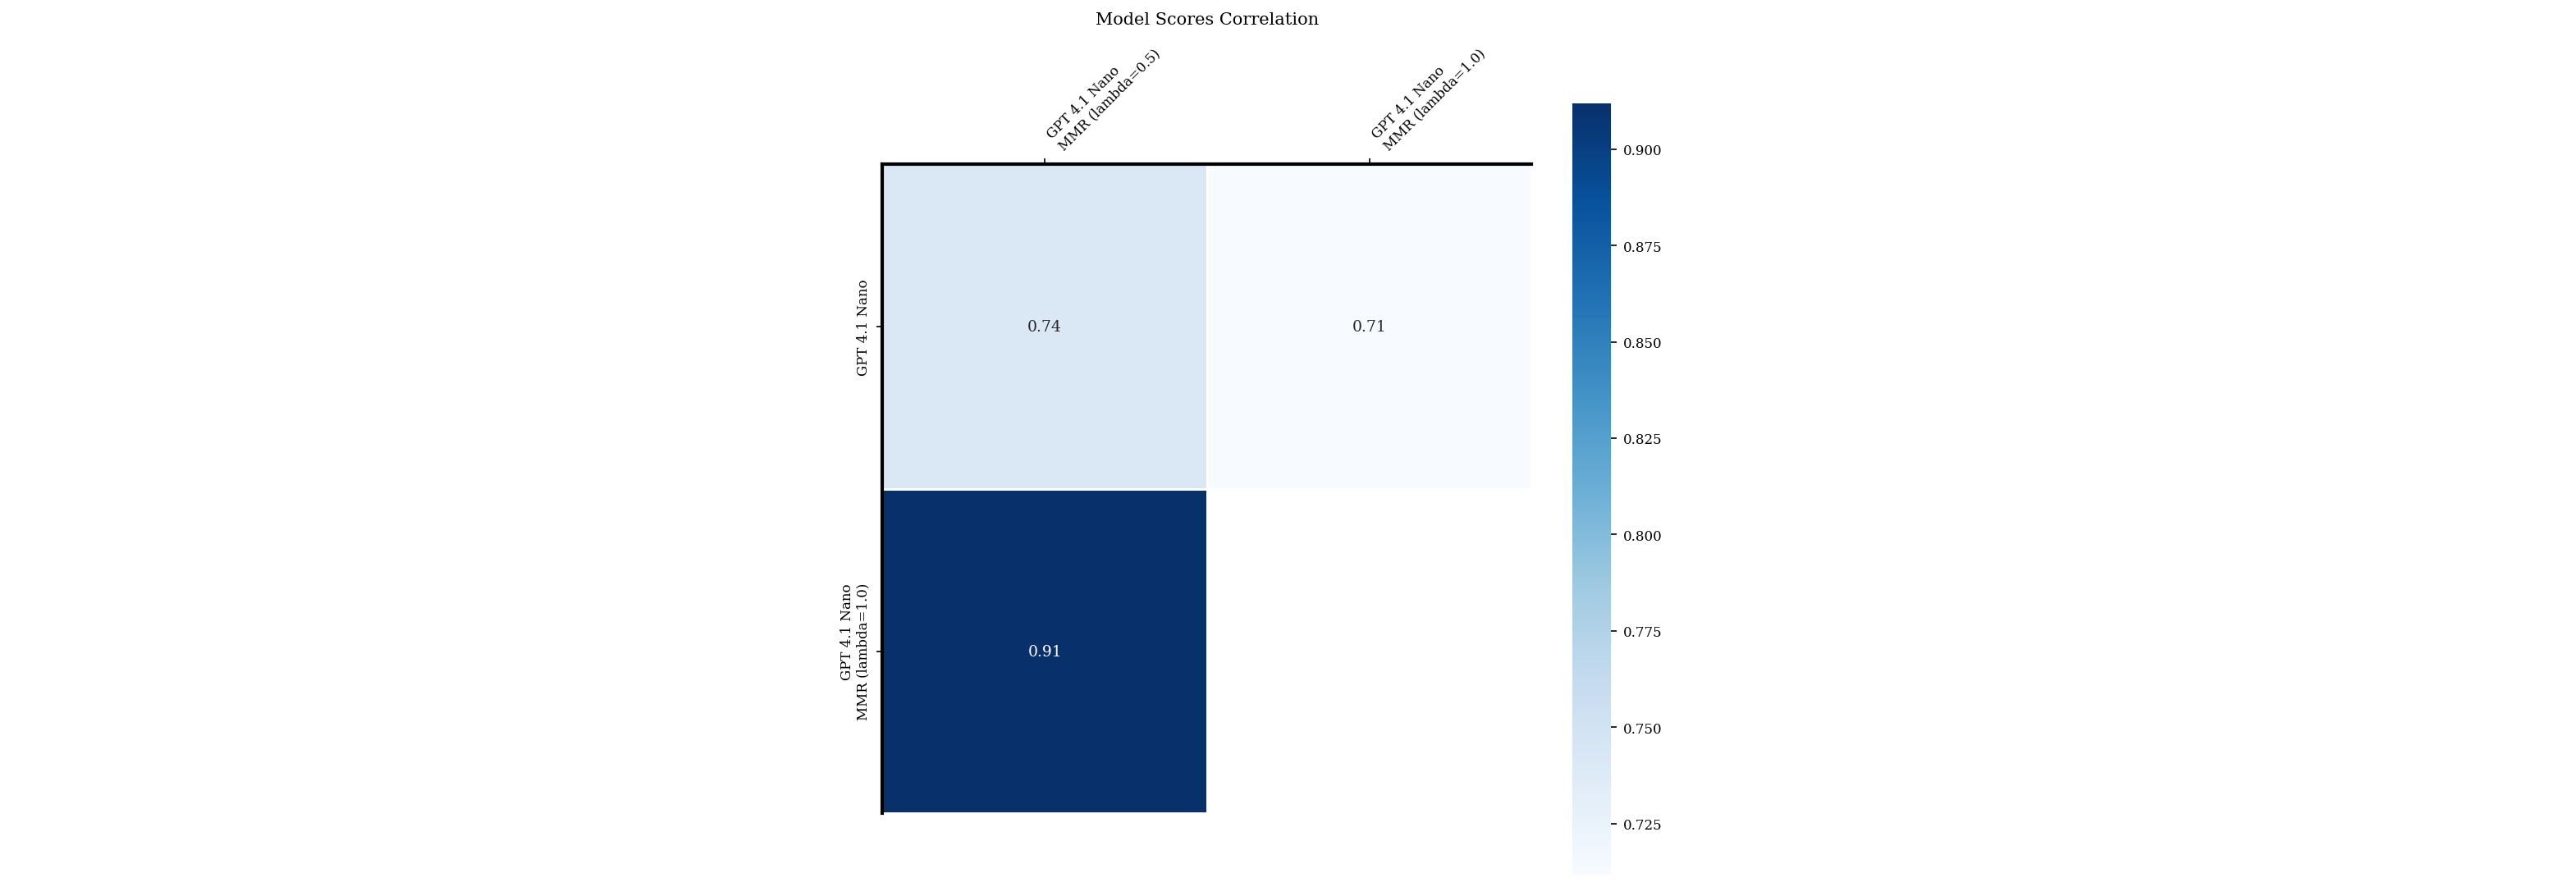

In [11]:
corr = scores.corr()
corr = corr[corr.columns[::-1]]
mask = np.tril(np.ones_like(corr, dtype=bool), k=0)
mask = mask[:, ::-1]

corr = corr.iloc[:-1, :-1]
mask = mask[:-1, :-1]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
# Whiten axes[0] and axes[2]
for i in [0, 2]:
    ax_i = axes[i]
    ax_i.set_facecolor("white")
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    for spine in ax_i.spines.values():
        spine.set_visible(False)
    
ax = axes[1]
sns.heatmap(corr, mask=mask, cmap='Blues', annot=True,
                 fmt=".2f", square=True, linewidths=0.5, ax=ax)
                 #vmin=-1, vmax=1, center=0, ax=ax)
ax.set_facecolor("white")
ax.set_title("Model Scores Correlation")
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

ax.spines['top'].set_visible(True)
ax.spines['top'].set_color('black')
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(2)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')

plt.tight_layout()
plt.show()

In [12]:
corr

,GPT 4.1 Nano\nMMR (lambda=0.5),GPT 4.1 Nano\nMMR (lambda=1.0)
GPT 4.1 Nano,0.741077,0.711734
GPT 4.1 Nano\nMMR (lambda=1.0),0.911908,1.000000


In [13]:
couples = []
for i in range(len(corr)):
    for j in range(len(corr) - i):
        couples.append((i, j, corr.index[i], corr.columns[j]))

In [14]:
import matplotlib.pyplot as plt
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [15]:
couples

[(0, 0, 'GPT 4.1 Nano', 'GPT 4.1 Nano\nMMR (lambda=0.5)'),
 (0, 1, 'GPT 4.1 Nano', 'GPT 4.1 Nano\nMMR (lambda=1.0)'),
 (1, 0, 'GPT 4.1 Nano\nMMR (lambda=1.0)', 'GPT 4.1 Nano\nMMR (lambda=0.5)')]

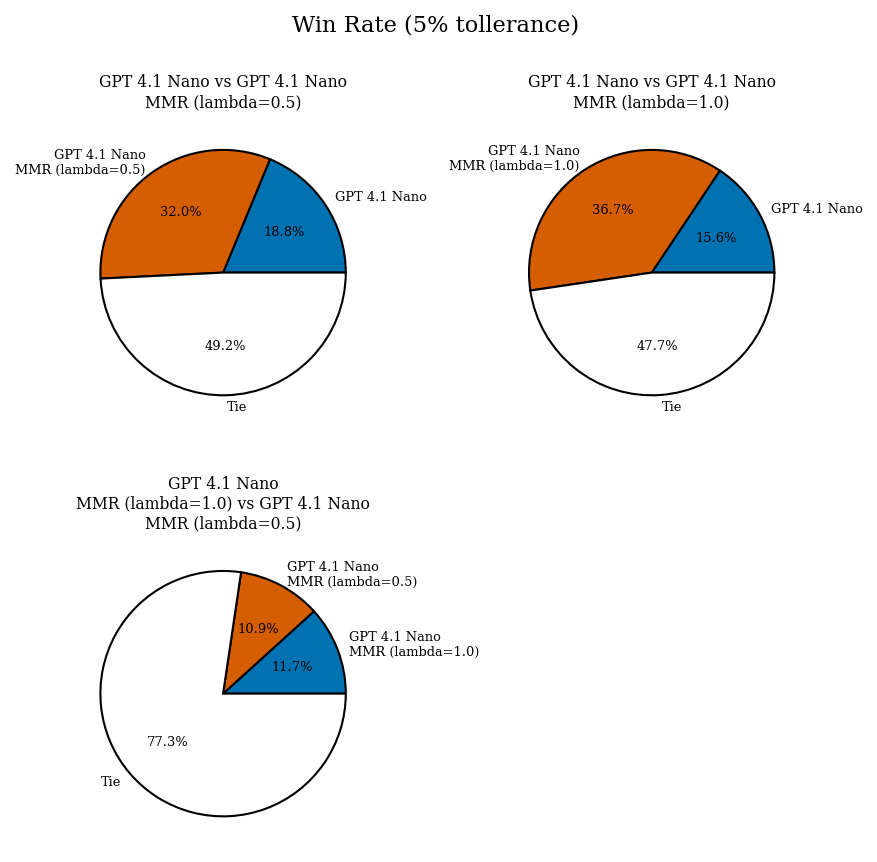

In [16]:
with plt.style.context('tableau-colorblind10'):
    fig, axes = plt.subplots(len(corr), len(corr), figsize=(5.9, 5.9))
    tol = 0.05
    fig.suptitle(f'Win Rate ({round(100*tol)}% tollerance) ')
    for c in couples:
        if isinstance(axes, np.ndarray):
            ax = axes[c[0], c[1]]
        else:
            ax = axes
        m1_name = c[2]
        m2_name = c[3]
        m1 = scores[m1_name]
        m2 = scores[m2_name]
        
        counts = {
            f'{m1_name}': (m1 > m2 + tol).sum(),
            f'{m2_name}': (m2 > m1 + tol).sum(),
            f'Tie': ((m1 - m2).abs() <= tol).sum()
        }
            
        ax.pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%',
            colors=["#0072B2", '#D55E00', "#ffffff"],
            wedgeprops={'edgecolor': 'black', 'linewidth': 1}, textprops={'fontsize': 'x-small'})
        ax.set_title(f'{m1_name} vs {m2_name}', fontsize='small')

    if isinstance(axes, np.ndarray):
        for i in range(1, len(axes)):
            for j in range(len(axes)-i, len(axes)):
                axes[i, j].set_visible(False) 
    plt.tight_layout()
    plt.show()

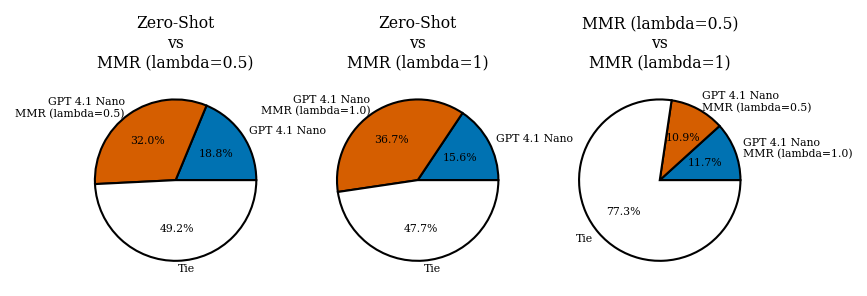

In [17]:
titles = ['Zero-Shot\nvs\nMMR (lambda=0.5)', 'Zero-Shot\nvs\nMMR (lambda=1)', 'MMR (lambda=0.5)\nvs\nMMR (lambda=1)']

with plt.style.context('tableau-colorblind10'):
    fig, axes = plt.subplots(1, 3, figsize=(5.9, 2))
    tol = 0.05
    #fig.suptitle(f'Win Rate ({round(100*tol)}% tollerance) ')
    for i, c in enumerate(couples):
        if isinstance(axes, np.ndarray):
            ax = axes[i]
        else:
            ax = axes
        m1_name = c[2]
        m2_name = c[3]
        m1 = scores[m1_name]
        m2 = scores[m2_name]
        
        counts = {
            f'{m1_name}': (m1 > m2 + tol).sum(),
            f'{m2_name}': (m2 > m1 + tol).sum(),
            f'Tie': ((m1 - m2).abs() <= tol).sum()
        }
            
        ax.pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%',
            colors=["#0072B2", '#D55E00', "#ffffff"],
            wedgeprops={'edgecolor': 'black', 'linewidth': 1}, textprops={'fontsize': 'xx-small'})
        #ax.set_title(f'{m1_name} vs {m2_name}', fontsize='small')
        ax.set_title(titles[i], fontsize='small')

    
    #plt.tight_layout()
    plt.savefig("model_comparison_MMR_winrate.pdf", bbox_inches="tight", dpi=300)
    plt.show()

In [18]:

from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests

In [19]:
scores.head()

,GPT 4.1 Nano,GPT 4.1 Nano\nMMR (lambda=1.0),GPT 4.1 Nano\nMMR (lambda=0.5)
id,,,
51,0.621469,0.706215,0.706215
57,0.734463,0.687382,0.677966
61,0.781689,0.649862,0.649862
66,0.762712,0.677966,0.706215
73,0.847458,0.847458,0.847458


In [20]:
stat, p = friedmanchisquare(scores.iloc[:, 0], scores.iloc[:, 1], scores.iloc[:, 2])
print("Friedman χ² =", stat, "p-value =", p)

Friedman χ² = 8.955 p-value = 0.011361782134002721


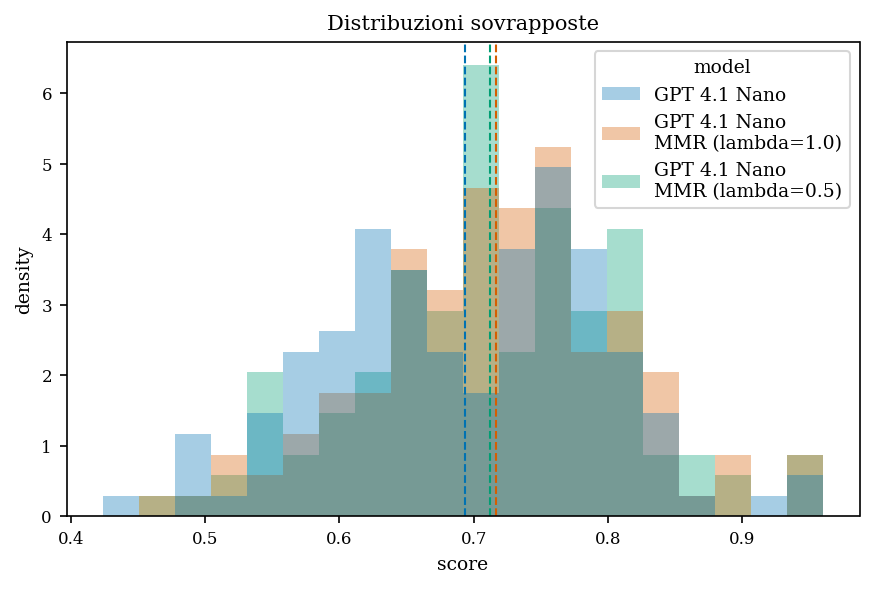

In [21]:
def plot_overlaid_hist(df, bins=20, figsize=(5.9, 4)):
    df_long = df[list(df.columns)].melt(var_name="model", value_name="score")
    plt.figure(figsize=figsize)
    sns.histplot(data=df_long, x="score", hue="model",
                 bins=bins, stat="density", common_norm=False,
                 alpha=0.35, edgecolor=None)
    # linee media
    for model, color in zip(df.columns, sns.color_palette(n_colors=len(df.columns))):
        plt.axvline(df[model].mean(), color=color, linestyle="--", linewidth=1)
    plt.xlabel("score")
    plt.ylabel("density")
    plt.title("Distribuzioni sovrapposte")
    plt.tight_layout()
    plt.show()

# Uso
plot_overlaid_hist(scores)

Shapiro d: p = 8.000492530555786e-09
Wilcoxon: W= 990.5 p= 0.19374934309262004 r= 0.6595048123169851


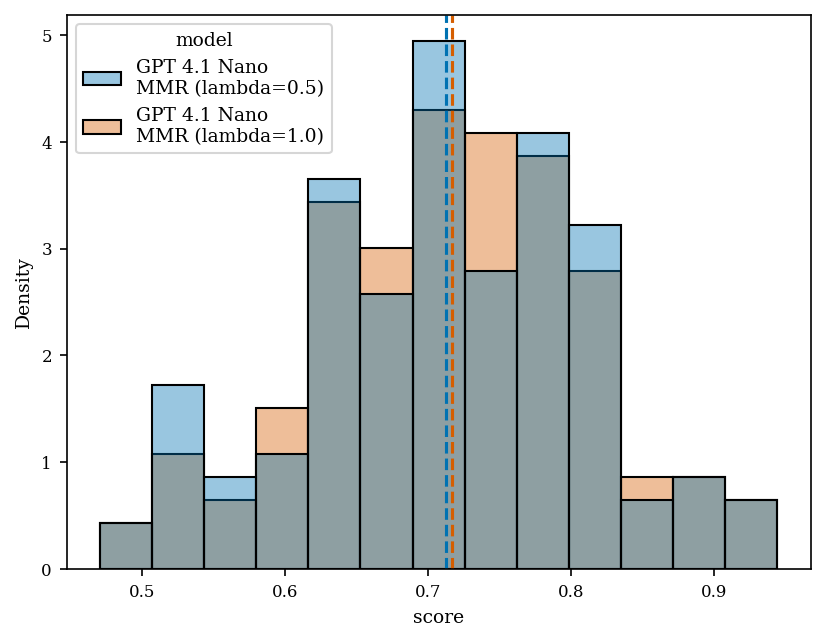

In [22]:
from scipy.stats import shapiro, ttest_rel, wilcoxon
from math import sqrt

a = 'GPT 4.1 Nano\nMMR (lambda=0.5)'
b = 'GPT 4.1 Nano\nMMR (lambda=1.0)'

# df con colonne 'A','B'
d = scores[a] - scores[b]

# 1. normality
stat_sh, p_sh = shapiro(d)
print("Shapiro d: p =", p_sh)

if p_sh > 0.05:
    # paired t-test
    t, p = ttest_rel(scores[a], scores[b])
    # Cohen's d (paired)
    d_mean = d.mean(); d_sd = d.std(ddof=1)
    cohens_d = d_mean / d_sd
    print("Paired t-test: t=", t, "p=", p, "Cohen's d=", cohens_d)
else:
    # Wilcoxon
    W, p = wilcoxon(scores[a], scores[b])
    # effect size r approx
    n = len(scores)
    mean_W = n*(n+1)/4
    sd_W = sqrt(n*(n+1)*(2*n+1)/24)
    z = (W - mean_W) / sd_W
    r = abs(z) / sqrt(n)
    print("Wilcoxon: W=", W, "p=", p, "r=", r)

# Plot histogram sovrapposto
df_long = scores[[a, b]].melt(var_name='model', value_name='score')
sns.histplot(data=df_long, x='score', hue='model', stat='density', common_norm=False, alpha=0.4)
plt.axvline(scores[a].mean(), color='C0', linestyle='--')
plt.axvline(scores[b].mean(), color='C1', linestyle='--')
plt.show()

In [23]:
# --- Funzioni utili ---
def cohens_d_paired(x, y):
    d = x - y
    return d.mean() / d.std(ddof=1)

def wilcoxon_r_from_W(W, n):
    mean_W = n*(n+1)/4
    sd_W = sqrt(n*(n+1)*(2*n+1)/24)
    z = (W - mean_W) / sd_W
    return abs(z) / sqrt(n)

def bootstrap_ci_diff(x, y, stat_func=np.mean, n_boot=5000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    diffs = x - y
    boot_stats = []
    n = len(diffs)
    for _ in range(n_boot):
        sample = rng.choice(diffs, size=n, replace=True)
        boot_stats.append(stat_func(sample))
    lo = np.percentile(boot_stats, 100*alpha/2)
    hi = np.percentile(boot_stats, 100*(1-alpha/2))
    return stat_func(diffs), (lo, hi)

def permutation_paired_pvalue(x, y, stat_func=np.mean, n_perm=5000, seed=0):
    rng = np.random.default_rng(seed)
    obs = stat_func(x - y)
    n = len(x)
    count = 0
    for _ in range(n_perm):
        signs = rng.choice([1, -1], size=n)
        perm = stat_func(signs * (x - y))
        if abs(perm) >= abs(obs):
            count += 1
    return obs, (count + 1) / (n_perm + 1)

# --- Main: carica i dati (sostituisci con il tuo df) ---
# Esempio: df = pd.read_csv("scores.csv") con colonne 'mmr_l1' e 'mmr_l05'
# Qui assumiamo df già presente
# df = pd.read_csv("path_to_file.csv")
# Per test rapido, puoi decommentare l'esempio seguente:
# np.random.seed(0)
# df = pd.DataFrame({
#     "mmr_l1": np.random.normal(0.70, 0.08, 128),
#     "mmr_l05": np.random.normal(0.71, 0.09, 128)
# })

def compare_mmr(df, col_a="GPT 4.1 Nano\nMMR (lambda=0.5)", col_b="GPT 4.1 Nano\nMMR (lambda=1.0)"):
    x = df[col_a].values
    y = df[col_b].values
    n = len(df)
    print(f"n = {n}\n")

    # differenze
    d = x - y

    # 1) Shapiro per normalità delle differenze
    stat_sh, p_sh = shapiro(d)
    print(f"Shapiro d: W = {stat_sh:.4f}, p = {p_sh:.6f}")

    # 2) Test principale: paired t-test o Wilcoxon
    if p_sh > 0.05:
        t, p = ttest_rel(x, y)
        d_mean = d.mean()
        cohens_d = cohens_d_paired(x, y)
        print("\nPaired t-test (differences approx. normal):")
        print(f"t = {t:.4f}, p = {p:.6f}")
        print(f"Mean diff ({col_a} - {col_b}) = {d_mean:.6f}")
        print(f"Cohen's d (paired) = {cohens_d:.4f}")
    else:
        W, p = wilcoxon(x, y)
        r = wilcoxon_r_from_W(W, n)
        med = np.median(d)
        print("\nWilcoxon signed-rank (non-parametric):")
        print(f"W = {W:.4f}, p = {p:.6f}")
        print(f"Median diff ({col_a} - {col_b}) = {med:.6f}")
        print(f"Effect size r = {r:.4f}")

    # 3) Bootstrap CI della differenza media (robusto)
    mean_diff, ci = bootstrap_ci_diff(x, y, stat_func=np.mean, n_boot=5000, seed=1)
    print(f"\nBootstrap mean diff = {mean_diff:.6f}, 95% CI = ({ci[0]:.6f}, {ci[1]:.6f})")

    # 4) Permutation paired test (mean diff)
    obs, p_perm = permutation_paired_pvalue(x, y, stat_func=np.mean, n_perm=5000, seed=2)
    print(f"Permutation test (mean diff): obs = {obs:.6f}, p_perm = {p_perm:.6f}")

    # 5) Percentuali e direzione
    pct_a_better = (d > 0).mean() * 100
    pct_b_better = (d < 0).mean() * 100
    ties_pct = (d == 0).mean() * 100
    print(f"\nPercentuale report: {col_a} > {col_b} = {pct_a_better:.1f}%, {col_b} > {col_a} = {pct_b_better:.1f}%, ties = {ties_pct:.1f}%")

    # 6) Plots
    sns.set(style="whitegrid")
    plt.figure(figsize=(8,4))
    # paired lines
    for i in range(n):
        plt.plot([0,1], [y[i], x[i]], color='gray', alpha=0.4)
    plt.scatter(np.zeros(n), y, label=col_b, color='C0')
    plt.scatter(np.ones(n), x, label=col_a, color='C1')
    plt.xticks([0,1], [col_b, col_a])
    plt.ylabel("score")
    plt.title("Paired scores per report")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # histogram of differences
    plt.figure(figsize=(6,4))
    sns.histplot(d, kde=True, stat="density")
    plt.axvline(0, color='k', linestyle='--')
    plt.xlabel(f"{col_a} - {col_b}")
    plt.title("Distribution of differences")
    plt.tight_layout()
    plt.show()

# Esempio di chiamata (decommenta se df è definito)
# compare_mmr(df)

n = 128

Shapiro d: W = 0.8785, p = 0.000000

Wilcoxon signed-rank (non-parametric):
W = 990.5000, p = 0.193749
Median diff (GPT 4.1 Nano
MMR (lambda=0.5) - GPT 4.1 Nano
MMR (lambda=1.0)) = 0.000000
Effect size r = 0.6595

Bootstrap mean diff = -0.004738, 95% CI = (-0.011813, 0.002100)
Permutation test (mean diff): obs = -0.004738, p_perm = 0.188162

Percentuale report: GPT 4.1 Nano
MMR (lambda=0.5) > GPT 4.1 Nano
MMR (lambda=1.0) = 21.1%, GPT 4.1 Nano
MMR (lambda=1.0) > GPT 4.1 Nano
MMR (lambda=0.5) = 32.8%, ties = 46.1%


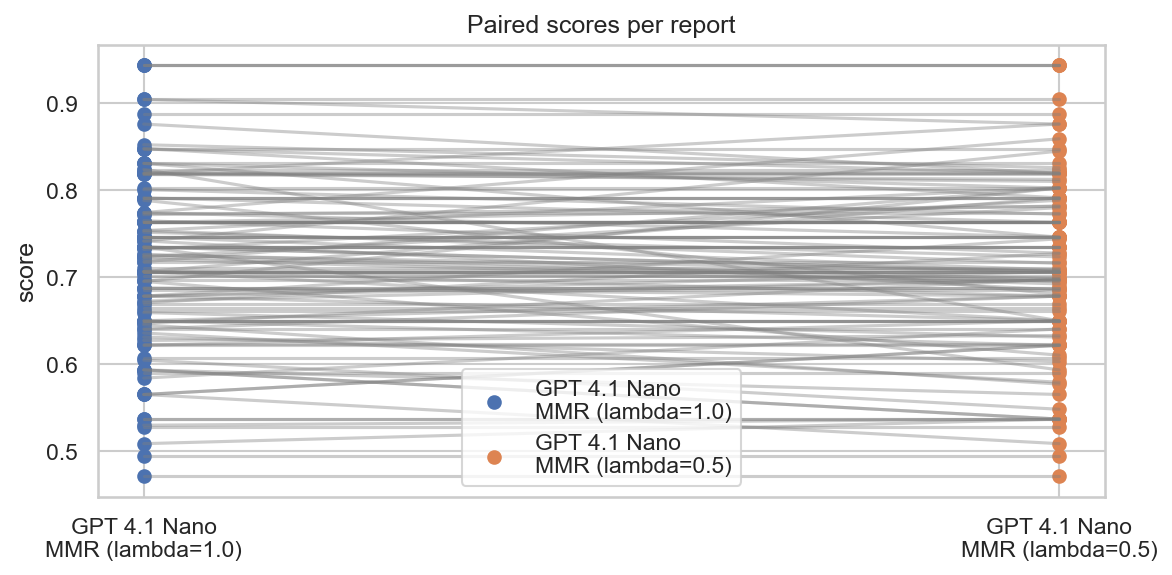

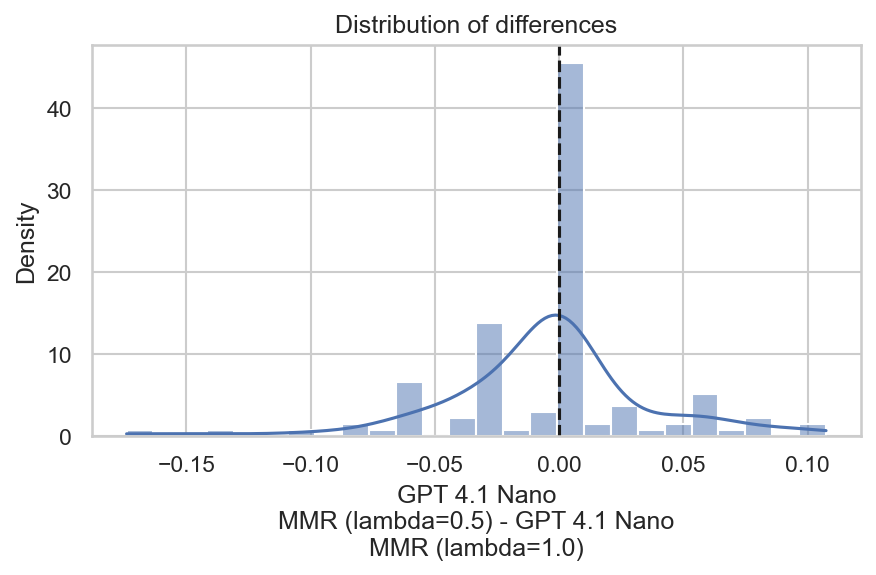

In [24]:
compare_mmr(scores, col_a='GPT 4.1 Nano\nMMR (lambda=0.5)', col_b='GPT 4.1 Nano\nMMR (lambda=1.0)')

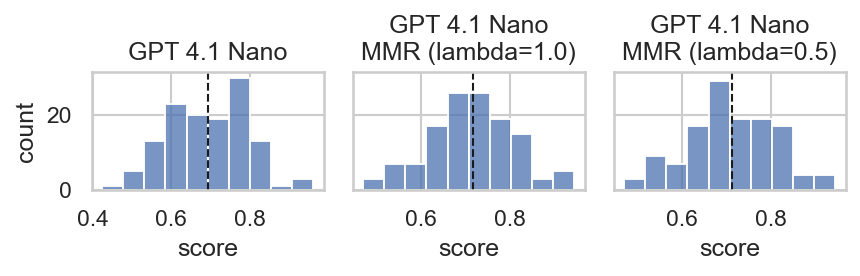

In [25]:
def plot_separate_hist(df, bins=20, figsize=(5.9,2)):
    fig, axes = plt.subplots(1, len(df.columns), figsize=figsize, sharey=True)
    for ax, col in zip(axes, df.columns):
        sns.histplot(df[col], kde=False, ax=ax, color="C0")
        ax.axvline(df[col].mean(), color="k", linestyle="--", linewidth=1)
        ax.set_title(col)
        ax.set_xlabel("score")
    axes[0].set_ylabel("count")
    plt.tight_layout()
    plt.show()

# Uso
plot_separate_hist(scores)

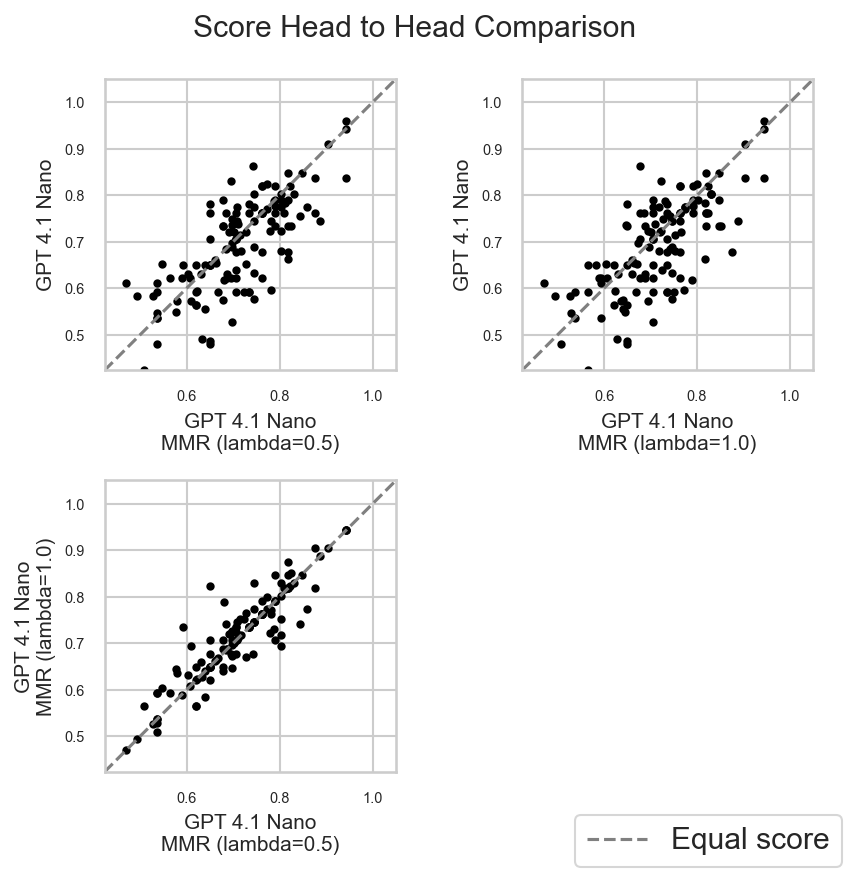

In [26]:
with plt.style.context('tableau-colorblind10'):

    fig, axes = plt.subplots(len(corr), len(corr), figsize=(5.9, 5.9))
    lo = scores.min(axis=None)
    for c in couples:
        
        if isinstance(axes, np.ndarray):
            ax = axes[c[0], c[1]]
        else:
            ax = axes
        y = scores[c[2]]
        x = scores[c[3]]

        ax.scatter(x, y, marker='.', color='black')

        # dashed diagonal line
        #lo = min(x.min(), y.min())
        ax.axline((lo, lo), slope=1, ls='--', color='grey', label=f'Equal score')
        #ax.axline((0, 0), slope=1, ls='--', color='grey', label=f'Equal score')
        ax.set_aspect('equal')
        ax.set_box_aspect(1)
        ax.set_ylabel(c[2], fontsize='small')
        ax.set_xlabel(c[3], fontsize='small')
        ax.tick_params(axis='both', labelsize='xx-small')
        ax.set_xlim((lo, 1.05))
        ax.set_ylim((lo, 1.05))
    if isinstance(axes, np.ndarray):
        for ax in axes.flat:
            if not ax.collections:
                ax.set_visible(False)
    #fig.legend()
    # Grab handle/label from any one subplot to avoid duplicates
    handles, labels = axes.flat[0].get_legend_handles_labels() if isinstance(axes, np.ndarray) else axes.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower right', fontsize='large')
    fig.suptitle(f'Score Head to Head Comparison')
    plt.tight_layout()
    plt.show()

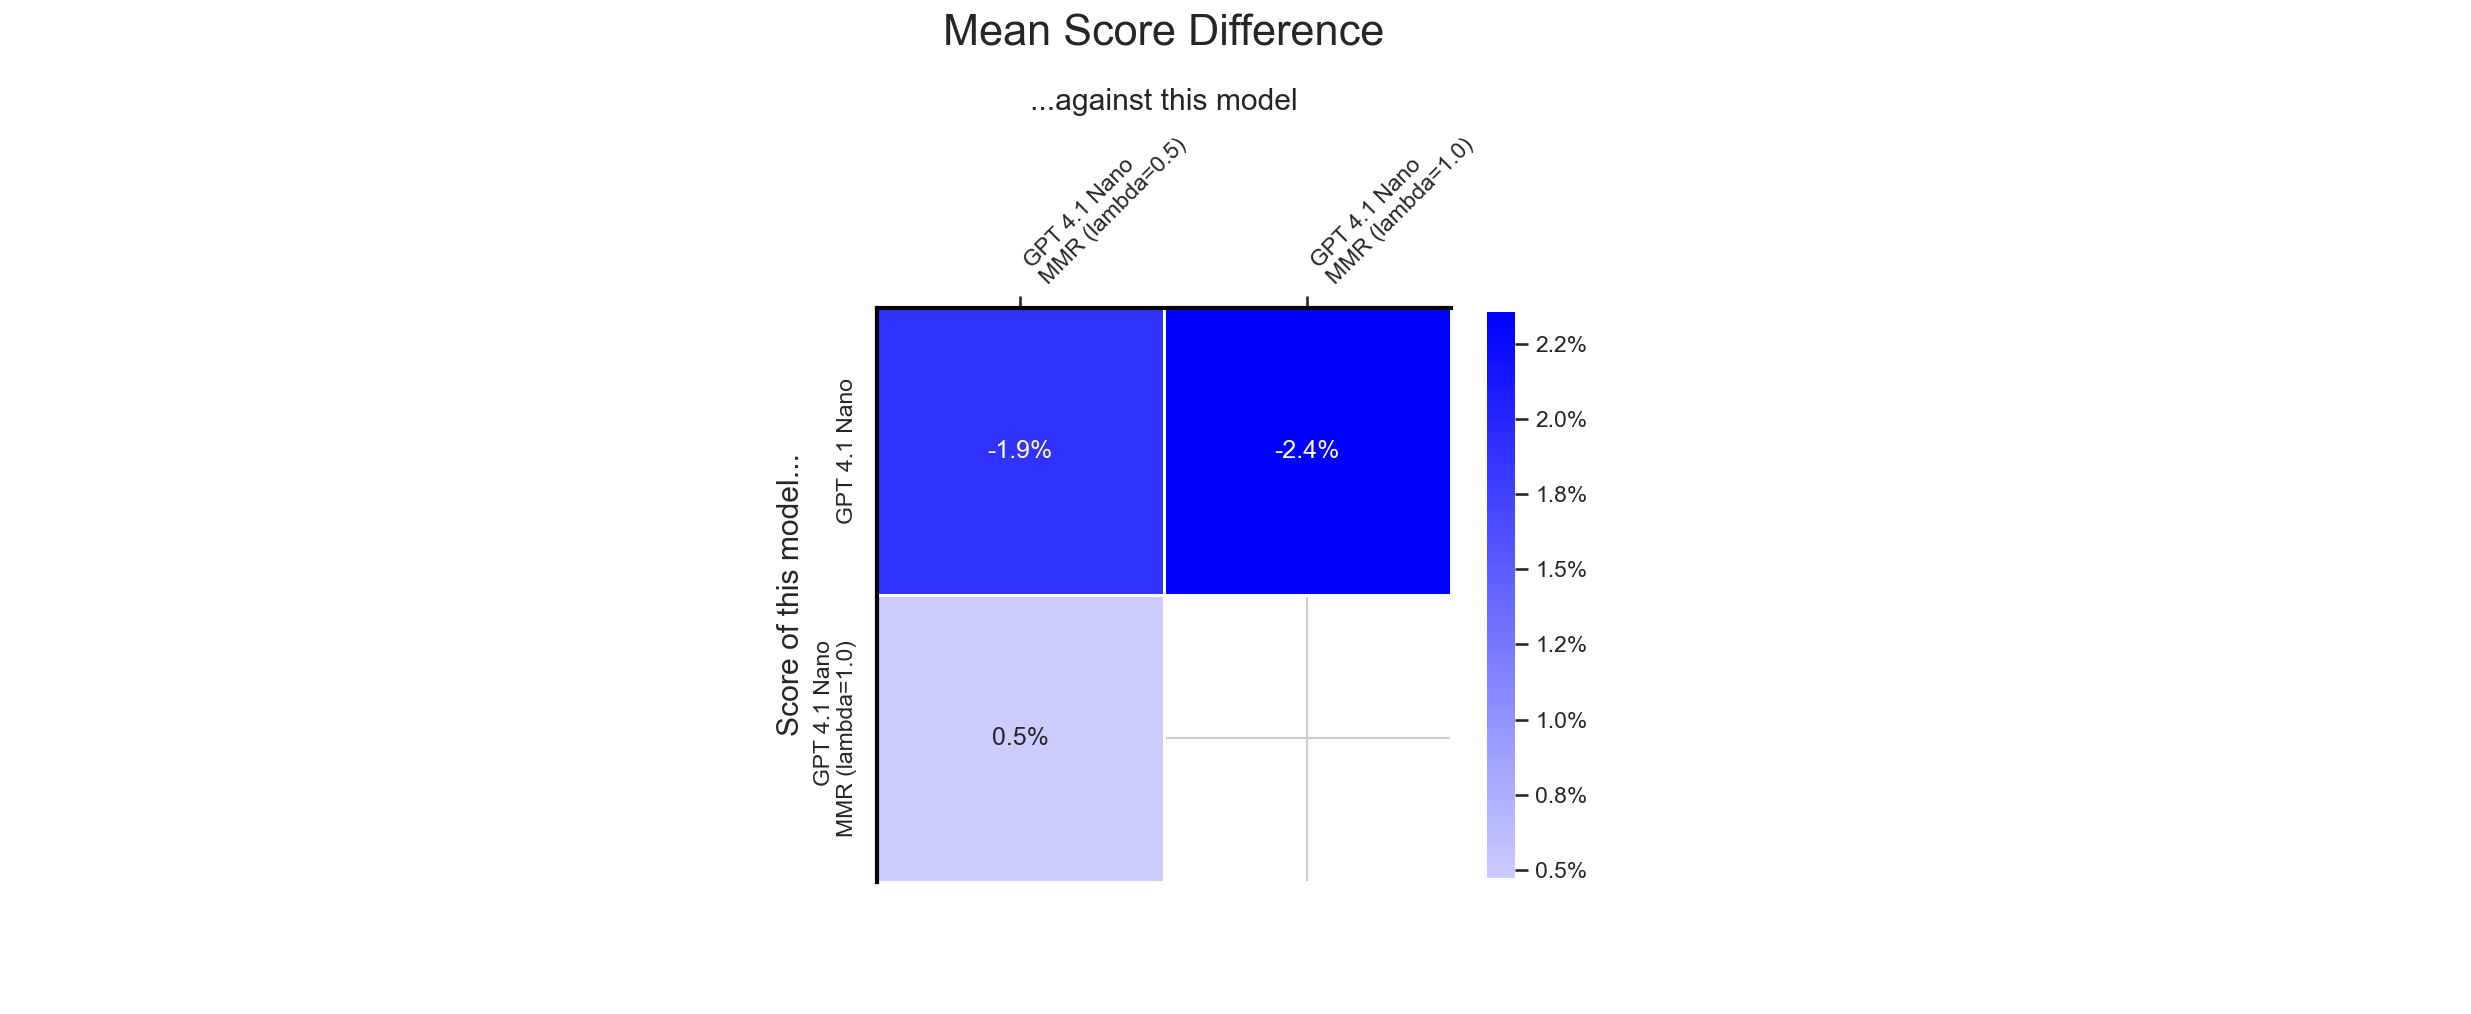

In [27]:
models = scores.columns.tolist()
n = len(models)

diff = pd.DataFrame(index=models, columns=models, dtype=float)

for i in models:
    for j in models:
        diff.loc[i, j] = (scores[i] - scores[j]).mean()


diff = diff[diff.columns[::-1]]
mask = np.tril(np.ones_like(diff, dtype=bool), k=0)
mask = mask[:, ::-1]

diff = diff.iloc[:-1, :-1]
mask = mask[:-1, :-1]


diff_pct = diff * 100

annot_labels = diff_pct.map(lambda x: f"{x:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
ax = axes[1]
# Whiten axes[0] and axes[2]
for i in [0, 2]:
    ax_i = axes[i]
    ax_i.set_facecolor("white")
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    for spine in ax_i.spines.values():
        spine.set_visible(False)

sns.heatmap(diff_pct.abs(), annot=annot_labels, fmt="", cmap=red_white_blue,
                 square=True, linewidths=0.5, mask=mask, ax=ax, center=0, cbar_kws={"shrink": 0.7})

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1f}%")

ax.set_title("Mean Score Difference", pad=20, fontsize='xx-large')
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_ylabel('Score of this model...', fontsize='large')
ax.set_xlabel('...against this model', fontsize='large')
ax.set_facecolor("white")

ax.spines['top'].set_visible(True)
ax.spines['top'].set_color('black')
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')


#plt.tight_layout()
plt.show()

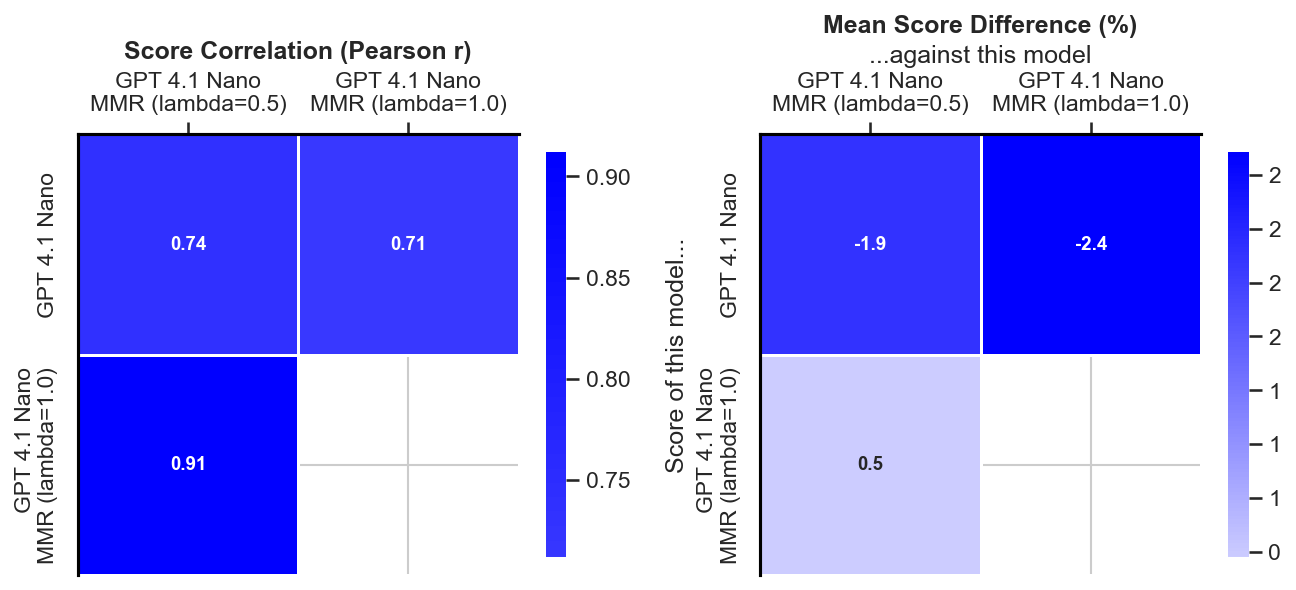

In [28]:
# --- Dati ---
# Correlazione
corr = scores.corr()
corr = corr[corr.columns[::-1]]
mask_corr = np.tril(np.ones_like(corr, dtype=bool), k=0)[:, ::-1]
corr = corr.iloc[:-1, :-1]
mask_corr = mask_corr[:-1, :-1]

# Differenza
models = scores.columns.tolist()
diff = pd.DataFrame(index=models, columns=models, dtype=float)
for i in models:
    for j in models:
        diff.loc[i, j] = (scores[i] - scores[j]).mean()

diff = diff[diff.columns[::-1]]
mask_diff = np.tril(np.ones_like(diff, dtype=bool), k=0)[:, ::-1]
diff = diff.iloc[:-1, :-1]
mask_diff = mask_diff[:-1, :-1]
diff_pct = diff * 100
annot_labels = diff_pct.map(lambda x: f"{x:.1f}")

# --- Figura ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))

# Stile comune
heatmap_kw = dict(square=True, linewidths=0.5, annot_kws={"size": 9, "fontweight": "bold"})
tick_kw = dict(labelsize=8)
spine_kw = dict(color="black", linewidth=1.5)

# --- Correlazione ---
sns.heatmap(
    corr, mask=mask_corr, cmap=red_white_blue, center=0,annot=True, fmt=".2f",
    ax=ax1, cbar_kws={"shrink": 0.6}, **heatmap_kw
)
ax1.set_title("Score Correlation (Pearson r)", fontdict={"fontsize": 12, "fontweight": "bold"})
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position("top")
#ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="left", fontsize=10)
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=10)
ax1.set_facecolor("white")
ax1.spines["top"].set(**spine_kw, visible=True)
ax1.spines["left"].set(**spine_kw, visible=True)

# --- Differenza ---
sns.heatmap(
    diff_pct.abs(), mask=mask_diff, annot=annot_labels, fmt="",
    cmap=red_white_blue, center=0, ax=ax2,
    cbar_kws={"shrink": 0.6, "format": lambda x, _: f"{x:.0f}"}, **heatmap_kw
)
ax2.set_title("Mean Score Difference (%)", fontdict={"fontsize": 12, "fontweight": "bold"})
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position("top")
ax2.set_ylabel("Score of this model...", fontsize=12)
ax2.set_xlabel("...against this model", fontsize=12)
#ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="left", fontsize=10)
#ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=10)
ax2.set_facecolor("white")
ax2.spines["top"].set(**spine_kw, visible=True)
ax2.spines["left"].set(**spine_kw, visible=True)

plt.tight_layout()
plt.savefig("model_comparison_heatmaps_MMR.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [58]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,          # i caption in LaTeX sono spesso 9-10pt
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 150,       # per la preview; il salvataggio usa il suo
})

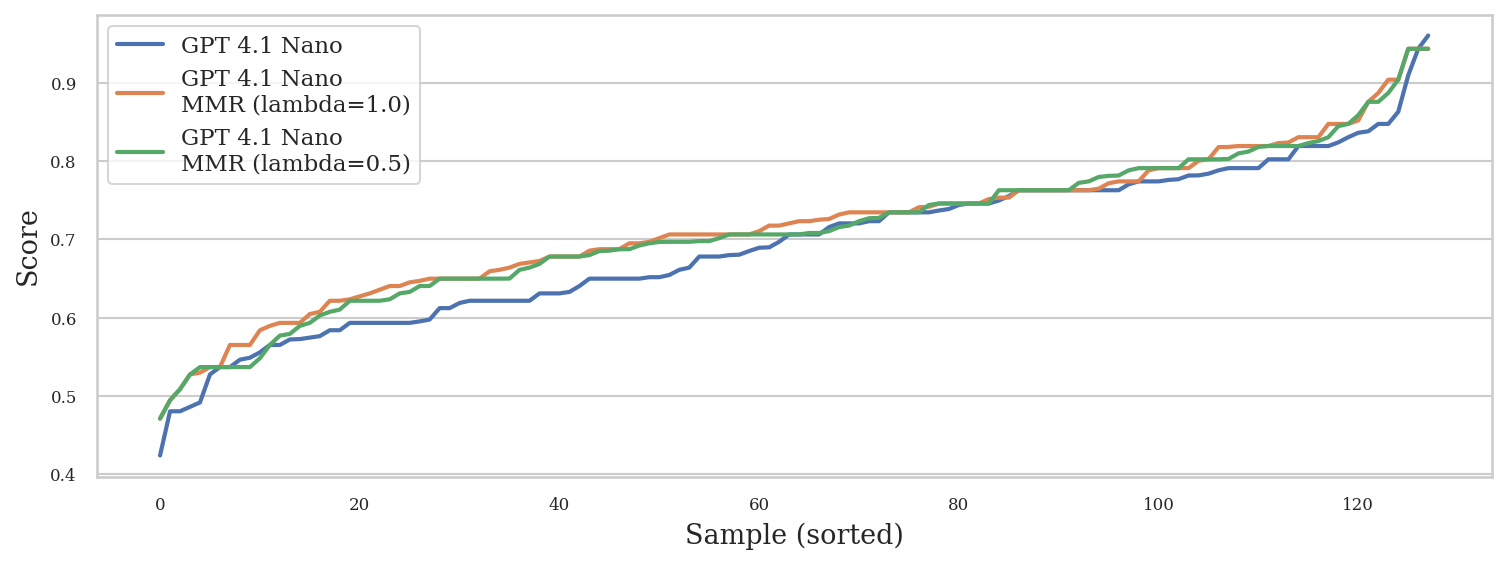

In [67]:
sorted_scores = scores.apply(lambda col: col.sort_values().reset_index(drop=True))

x = np.arange(len(sorted_scores))
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

for m in sorted_scores.columns:
    ax.plot(x, sorted_scores[m], label=m, linewidth=2)

ax.legend()
ax.set_xlabel('Sample (sorted)', fontsize='x-large')
ax.set_ylabel('Score', fontsize='x-large')
ax.grid(axis='x')
plt.savefig("ordered_scores_MMR.pdf", bbox_inches="tight", dpi=300)

Rolling window: 7


C:\Users\lucat\AppData\Local\Temp\ipykernel_13532\4190068721.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(cumulative_ordered_score.index, rotation=90, ha='right')


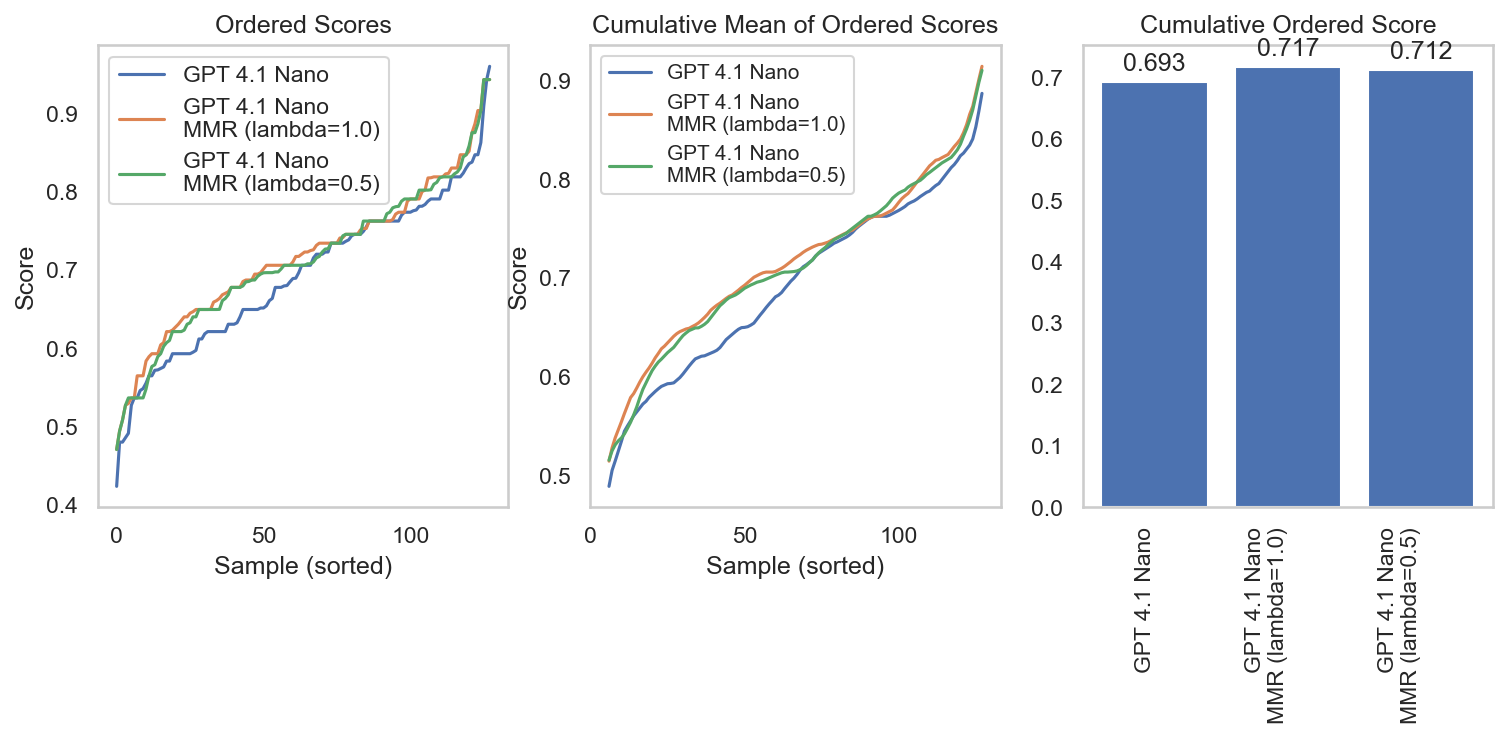

In [47]:
rolling_window =1 + int(0.05 * len(scores))

print(f"Rolling window: {rolling_window}")
sorted_scores = scores.apply(lambda col: col.sort_values().reset_index(drop=True))
#cumulative_mean = sorted_scores.expanding().mean()
rolling_mean = sorted_scores.rolling(window=rolling_window).mean()
#cumulative_ordered_score = cumulative_mean.mean()
cumulative_ordered_score = rolling_mean.mean()

x = np.arange(len(sorted_scores))
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

for m in sorted_scores.columns:
    ax1.plot(x, sorted_scores[m], label=m)
    ax2.plot(x, rolling_mean[m], label=m)
    #ax2.plot(x, cumulative_mean[m], label=m)

bars = ax3.bar(cumulative_ordered_score.index, cumulative_ordered_score.values)
ax3.bar_label(bars, fmt='%.3f', padding=3)

ax1.legend()
ax1.set_xlabel('Sample (sorted)')
ax1.set_ylabel('Score')
ax1.set_title('Ordered Scores')
ax1.grid(False)


ax2.set_xlabel('Sample (sorted)')
ax2.set_ylabel('Score')
ax2.set_title('Cumulative Mean of Ordered Scores')
ax2.legend(fontsize='small')
ax2.grid(False)


ax3.set_xlabel('')
ax3.set_xticklabels(cumulative_ordered_score.index, rotation=90, ha='right')
ax3.set_title('Cumulative Ordered Score')
ax3.grid(False)


In [45]:
scores.mean()

GPT 4.1 Nano                      0.693314
GPT 4.1 Nano\nMMR (lambda=1.0)    0.716874
GPT 4.1 Nano\nMMR (lambda=0.5)    0.712137
dtype: float64

In [44]:
rolling_mean.dropna()

,GPT 4.1 Nano,GPT 4.1 Nano\nMMR (lambda=1.0),GPT 4.1 Nano\nMMR (lambda=0.5)
2,0.461394,0.491212,0.491212
3,0.482109,0.510044,0.510044
4,0.485876,0.521814,0.524168
5,0.501569,0.531230,0.533584
6,0.518519,0.534369,0.536723
...,...,...,...
123,0.844319,0.888889,0.879473
124,0.852637,0.898305,0.888889
125,0.873352,0.917137,0.911488
126,0.905367,0.930320,0.930320


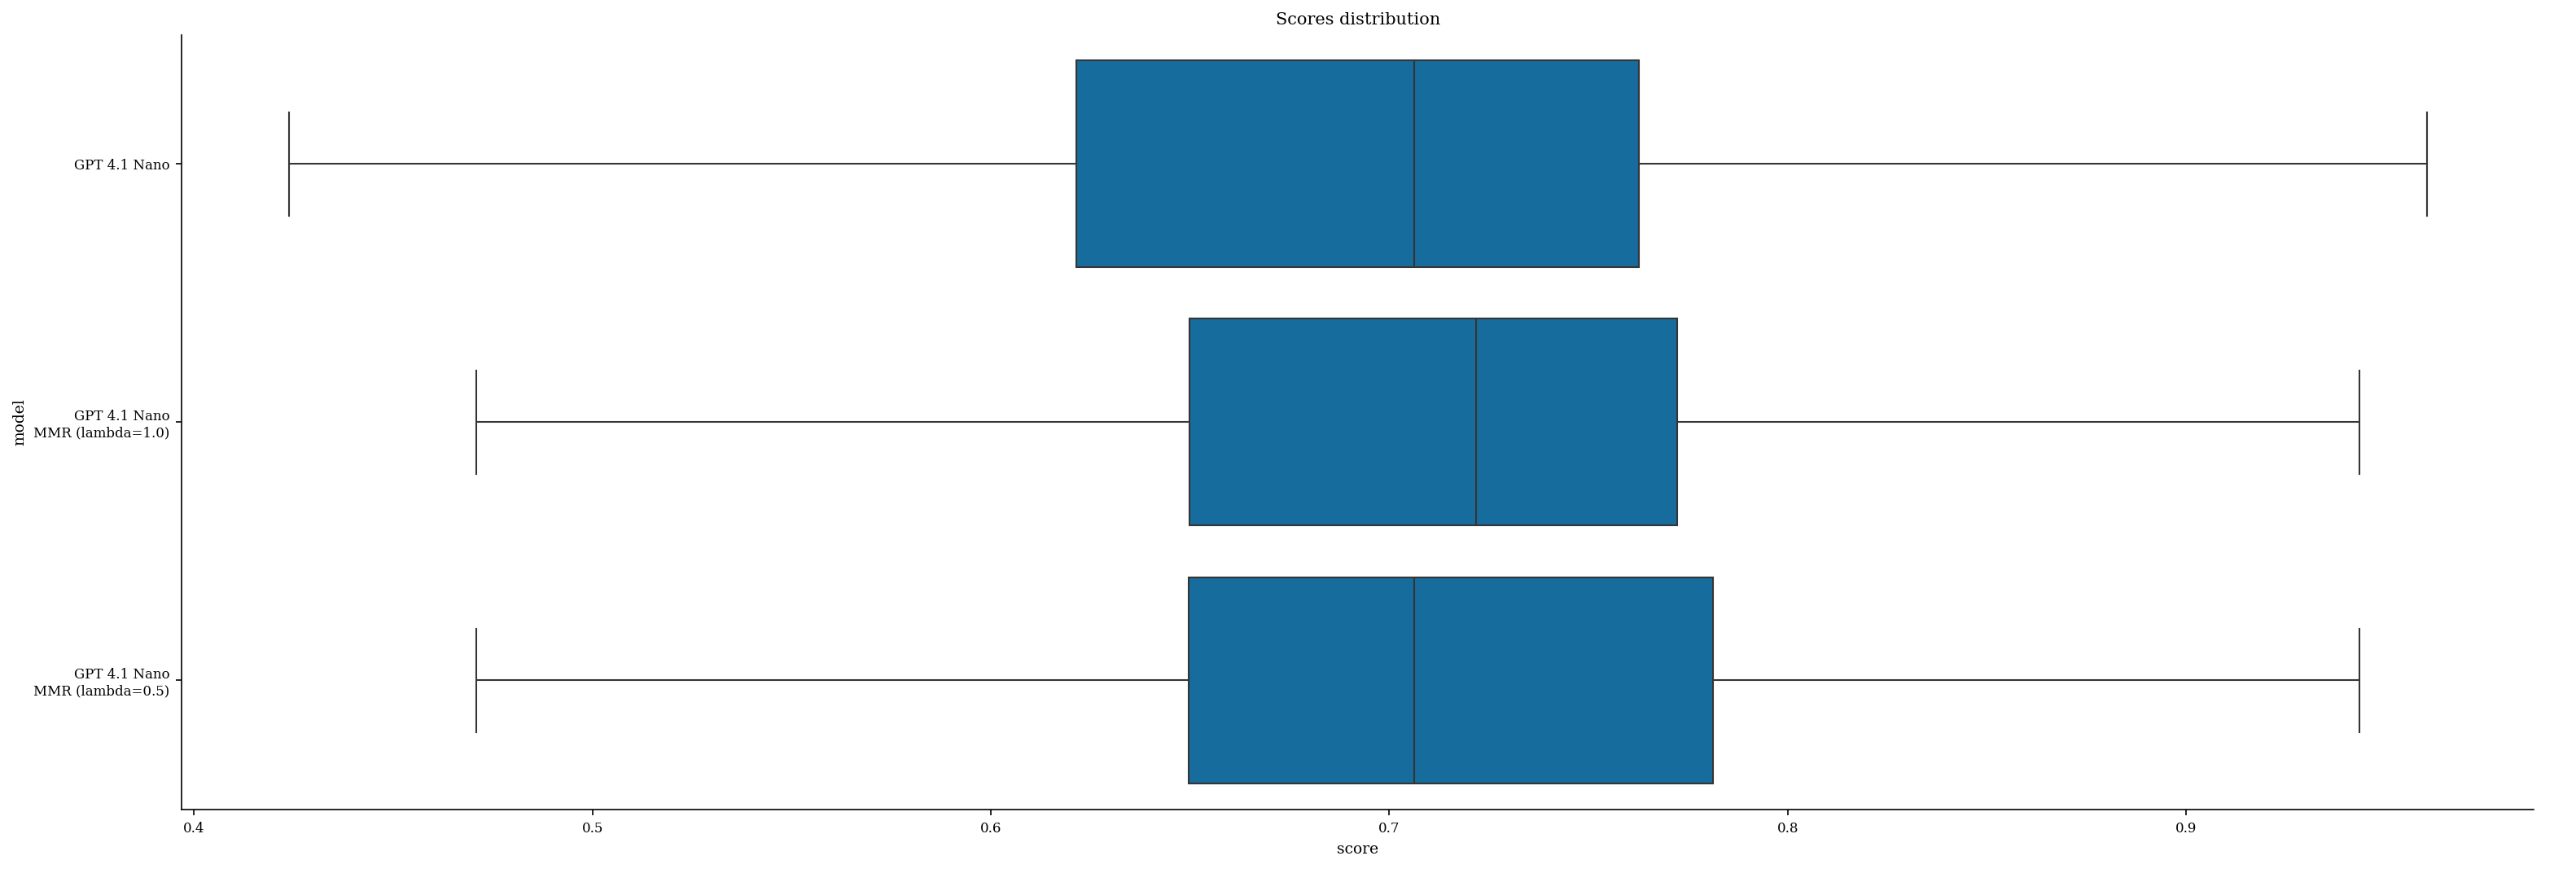

In [72]:
# Normalizziamo COS tra 0 e 1
#norm_scores = (cumulative_ordered_score - cumulative_ordered_score.min()) / (cumulative_ordered_score.max() - cumulative_ordered_score.min())



#print(cumulative_ordered_score)
#palette_sharpe_scores = {model: red_white_blue(norm_scores[model]) for model in cumulative_ordered_score.index}

scores_melted = scores.melt(var_name='model', value_name='score')
sns.catplot(data=scores_melted, y="model", x="score", kind='box', height=7, aspect=21/7)
plt.title("Scores distribution")
plt.show()

In [73]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,          # i caption in LaTeX sono spesso 9-10pt
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 150,       # per la preview; il salvataggio usa il suo
})

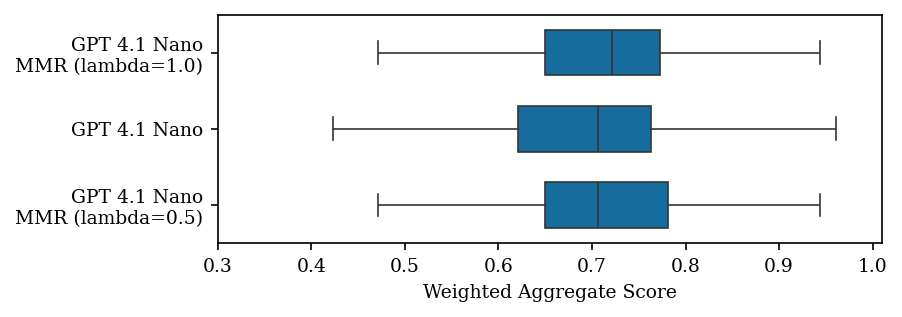

In [74]:
scores_melted = scores.melt(var_name='model', value_name='score')

# Ordina per mediana decrescente
order = scores_melted.groupby('model')['score'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(5.9, 2), constrained_layout=True)

sns.boxplot(
    data=scores_melted,
    y="model",
    x="score",
    order=order,
    ax=ax,
    linewidth=0.8,
    fliersize=3,
    width=0.6,
)

ax.set_xlabel("Weighted Aggregate Score")
ax.set_ylabel(None)
ax.tick_params(labelsize=9)
ax.set_xlim(0.3, 1.01)

#plt.tight_layout()
plt.savefig("boxplot_scores_MMR.pdf", bbox_inches="tight", dpi=150)
plt.show()

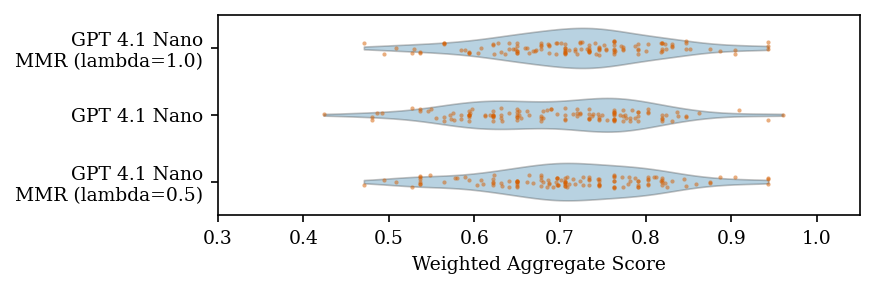

In [75]:
fig, ax = plt.subplots(figsize=(5.9, 2))

sns.violinplot(
    data=scores_melted,
    y="model",
    x="score",
    order=order,
    ax=ax,
    linewidth=0.8,
    width=0.6,
    inner=None,
    cut=0,
    alpha=0.3,
)

sns.stripplot(
    data=scores_melted,
    y="model",
    x="score",
    order=order,
    ax=ax,
    size=2,
    alpha=0.5,
    jitter=0.10,
)

ax.set_xlabel("Weighted Aggregate Score")
ax.set_ylabel(None)
ax.tick_params(labelsize=9)
ax.set_xlim(0.3, 1.05)

plt.tight_layout()
plt.savefig("violinplot_baseline_scores.pdf", bbox_inches="tight", dpi=300)
plt.show()